In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Fifa.csv")
df.head()

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


# EDA

In [3]:
# Dataset Overview
print("Dataset Shape:", df.shape)


Dataset Shape: (19667, 9)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  str    
 1   Country            19667 non-null  str    
 2   Position           19667 non-null  str    
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  str    
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 1.4 MB


In [5]:
# Basic Statistics
df.describe()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


In [6]:
# Duplicate Rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [7]:
# Unique Values for Categorical Columns
print("Unique Countries:", df['Country'].nunique())
print("Unique Positions:", df['Position'].nunique())
print("Unique Teams:", df['Team'].nunique())
print("\nPosition Distribution:")
print(df['Position'].value_counts().head(10))

Unique Countries: 164
Unique Positions: 17
Unique Teams: 1009

Position Distribution:
Position
CB     2981
ST     2697
CM     2507
GK     2124
CDM    1358
LM     1279
RM     1203
RB     1100
CAM    1099
LB     1073
Name: count, dtype: int64


In [8]:
# Check for potential outliers in numerical columns
import numpy as np

numerical_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Value Per M$', 'Total_Stats Score']
print("Outlier Detection (using IQR method):")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
    print(f"{col}: {outliers} outliers")

Outlier Detection (using IQR method):
Age: 169 outliers
Overall_Rating: 146 outliers
Future Potential: 120 outliers
Value Per M$: 2390 outliers
Total_Stats Score: 788 outliers


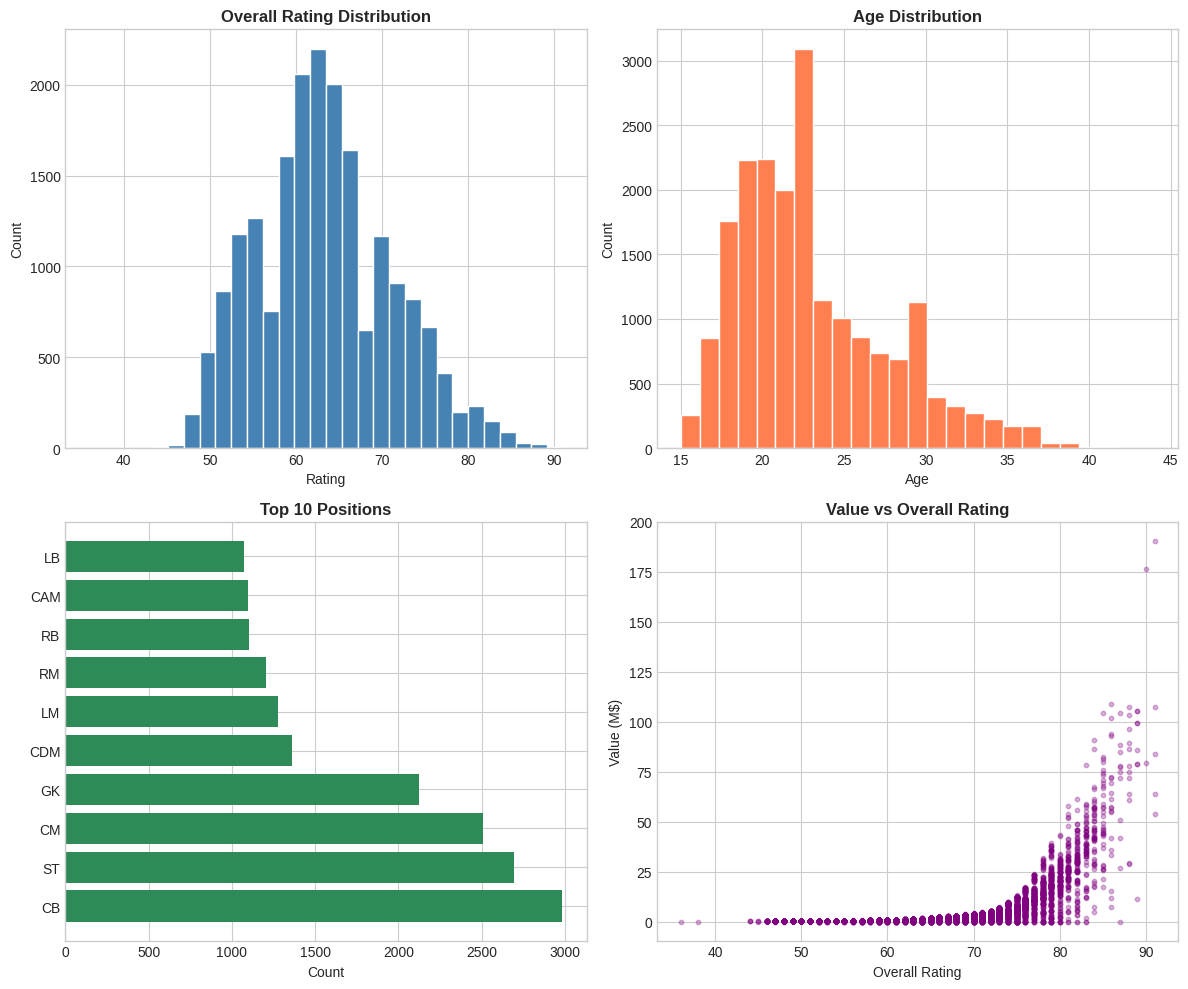

In [9]:

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Overall Rating Distribution
axes[0, 0].hist(df['Overall_Rating'], bins=30, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Overall Rating Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Rating')
axes[0, 0].set_ylabel('Count')

# 2. Age Distribution
axes[0, 1].hist(df['Age'], bins=25, color='coral', edgecolor='white')
axes[0, 1].set_title('Age Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Count')

# 3. Top 10 Positions
pos_counts = df['Position'].value_counts().head(10)
axes[1, 0].barh(pos_counts.index, pos_counts.values, color='seagreen')
axes[1, 0].set_title('Top 10 Positions', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Count')

# 4. Value vs Overall Rating
axes[1, 1].scatter(df['Overall_Rating'], df['Value Per M$'], alpha=0.3, s=10, color='purple')
axes[1, 1].set_title('Value vs Overall Rating', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Overall Rating')
axes[1, 1].set_ylabel('Value (M$)')

plt.tight_layout()
plt.show()

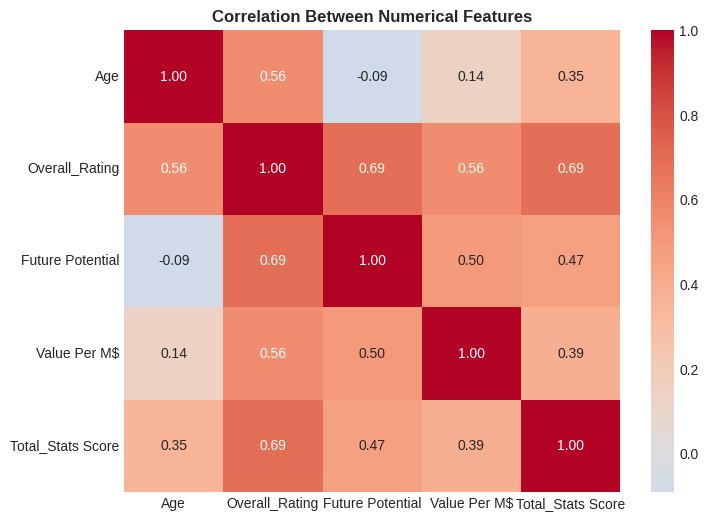

In [10]:
# Correlation Heatmap
numerical_df = df[['Age', 'Overall_Rating', 'Future Potential', 'Value Per M$', 'Total_Stats Score']]
plt.figure(figsize=(8, 6))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Between Numerical Features', fontsize=12, fontweight='bold')
plt.show()

# Preprocessing

In [11]:
# ── Classification target ────────────────────────────────────────────────────
def assign_tier(rating):
    if rating >= 85: return 'Elite'
    elif rating >= 75: return 'High'
    elif rating >= 65: return 'Mid'
    else: return 'Low'

df['Performance_Tier'] = df['Overall_Rating'].apply(assign_tier)

tier_order = ['Low', 'Mid', 'High', 'Elite']
df['Performance_Tier'] = pd.Categorical(df['Performance_Tier'],
                                        categories=tier_order, ordered=True)

print("Performance Tier distribution:")
print(df['Performance_Tier'].value_counts().sort_index())

# ── Regression target ────────────────────────────────────────────────────────
# Log-transform to handle right skew
df['Value_log'] = np.log1p(df['Value Per M$'])

Performance Tier distribution:
Performance_Tier
Low      11740
Mid       6124
High      1711
Elite       92
Name: count, dtype: int64


In [ ]:
# Targets to exclude from X
REGRESSION_TARGET   = 'Value_log'          # log-transformed
CLASSIFICATION_TARGET = 'Performance_Tier'

TARGET_COLS = ['Value Per M$', 'Value_log',
               'Performance_Tier', 'Overall_Rating']  # Overall_Rating defines tiers

# Feature groups
num_features      = ['Age', 'Future Potential', 'Total_Stats Score']


low_card_cat  = ['Position']         
high_card_cat = ['Country', 'Team']   


num_features_reg = num_features + ['Overall_Rating']


num_features_clf = num_features   

print("Numerical features (regression) :", num_features_reg)
print("Numerical features (classif.)   :", num_features_clf)
print("Low-cardinality categoricals    :", low_card_cat)
print("High-cardinality categoricals   :", high_card_cat)


Numerical features (regression) : ['Age', 'Future Potential', 'Total_Stats Score', 'Overall_Rating']
Numerical features (classif.)   : ['Age', 'Future Potential', 'Total_Stats Score']
Low-cardinality categoricals    : ['Position']
High-cardinality categoricals   : ['Country', 'Team']


In [13]:
from sklearn.model_selection import train_test_split


RANDOM_STATE = 42

# ── Features ─────────────────────────────────────────────────────────────────
all_features = num_features_reg + low_card_cat  

X = df[all_features].copy()
y_reg = df[REGRESSION_TARGET].copy()
y_clf = df[CLASSIFICATION_TARGET].copy()

# ── Stratified split (based on classification target) ────────────────────────
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_clf          
)

print(f"Train size : {len(X_train):,}  ({len(X_train)/len(X):.0%})")
print(f"Test size  : {len(X_test):,}   ({len(X_test)/len(X):.0%})")
print()
print("Tier distribution — train:")
print(y_clf_train.value_counts().sort_index())
print()
print("Tier distribution — test:")
print(y_clf_test.value_counts().sort_index())

Train size : 15,733  (80%)
Test size  : 3,934   (20%)

Tier distribution — train:
Performance_Tier
Low      9392
Mid      4899
High     1369
Elite      73
Name: count, dtype: int64

Tier distribution — test:
Performance_Tier
Low      2348
Mid      1225
High      342
Elite      19
Name: count, dtype: int64


In [14]:
# ── Sub-pipelines ──────────────────────────────────────────────────
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


numerical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # robust to skew / outliers
    ('scaler',  StandardScaler()),
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# ── ColumnTransformer for REGRESSION ─────────────────────────────────────────
preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', numerical_pipe,  num_features_reg),
        ('cat', categorical_pipe, low_card_cat),
    ],
    remainder='drop'   # silently drops any column not listed
)

# ── ColumnTransformer for CLASSIFICATION ─────────────────────────────────────
preprocessor_clf = ColumnTransformer(
    transformers=[
        ('num', numerical_pipe,  num_features_clf),
        ('cat', categorical_pipe, low_card_cat),
    ],
    remainder='drop'
)

print("Preprocessors defined ✓")
print()
print("Regression  preprocessor inputs :", num_features_reg + low_card_cat)
print("Classification preprocessor inputs:", num_features_clf + low_card_cat)


Preprocessors defined ✓

Regression  preprocessor inputs : ['Age', 'Future Potential', 'Total_Stats Score', 'Overall_Rating', 'Position']
Classification preprocessor inputs: ['Age', 'Future Potential', 'Total_Stats Score', 'Position']


In [ ]:
# ── Fit on TRAIN only  ──────────────────────────────────────
X_train_reg = preprocessor_reg.fit_transform(X_train)
X_test_reg  = preprocessor_reg.transform(X_test)

X_train_clf = preprocessor_clf.fit_transform(X_train)
X_test_clf  = preprocessor_clf.transform(X_test)

# ── Feature names after encoding ──────────────────────────────────────────────
feature_names_reg = preprocessor_reg.get_feature_names_out()
feature_names_clf = preprocessor_clf.get_feature_names_out()

print("=== Regression ===")
print(f"  X_train shape : {X_train_reg.shape}")

print()
print("=== Classification ===")
print(f"  X_train shape : {X_train_clf.shape}")


=== Regression ===
  X_train shape : (15733, 20)

=== Classification ===
  X_train shape : (15733, 19)


# Naive bayes

--- GaussianNB (Numerical Only) ---
Accuracy:  0.8500
Precision: 0.8473
Recall:    0.8500
F1-Score:  0.8470



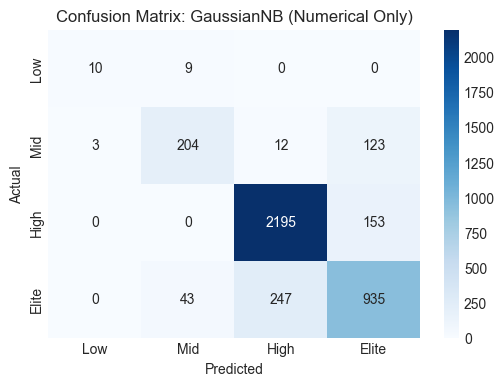

--- BernoulliNB (Full Set) ---
Accuracy:  0.7110
Precision: 0.7274
Recall:    0.7110
F1-Score:  0.6915



c:\Users\mosta\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


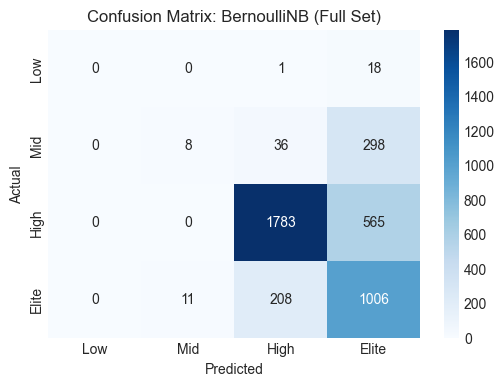

--- ComplementNB (Full Set) ---
Accuracy:  0.8012
Precision: 0.7415
Recall:    0.8012
F1-Score:  0.7673



c:\Users\mosta\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


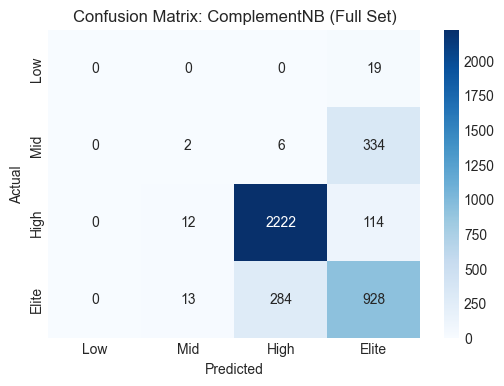

In [ ]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Initialize the models
models = {
    "GaussianNB (Numerical Only)": GaussianNB(),
    "BernoulliNB (Full Set)": BernoulliNB(),
    "ComplementNB (Full Set)": ComplementNB()
}

# According to requirements: Gaussian should only use numerical features
# (Age, Future Potential, Total_Stats Score)
# These are the first 3 indices in your processed array
X_train_num_only = X_train_clf[:, :3]
X_test_num_only = X_test_clf[:, :3]

# 2. Train and Evaluate each model
for name, model in models.items():
    if "Gaussian" in name:
        model.fit(X_train_num_only, y_clf_train)
        y_pred = model.predict(X_test_num_only)
    elif "Complement" in name:
        # ComplementNB requires non-negative values; 
        # Since we used StandardScaler (which centers at 0), we shift to non-negative
        X_train_shifted = X_train_clf - X_train_clf.min()
        X_test_shifted = X_test_clf - X_train_clf.min()
        model.fit(X_train_shifted, y_clf_train)
        y_pred = model.predict(X_test_shifted)
    else:
        model.fit(X_train_clf, y_clf_train)
        y_pred = model.predict(X_test_clf)

    # Metrics
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_clf_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_clf_test, y_pred, average='weighted'):.4f}")
    print(f"Recall:    {recall_score(y_clf_test, y_pred, average='weighted'):.4f}")
    print(f"F1-Score:  {f1_score(y_clf_test, y_pred, average='weighted'):.4f}\n")

    # 3. Confusion Matrix Heatmap
    plt.figure(figsize=(6, 4))
    cm = confusion_matrix(y_clf_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=tier_order, yticklabels=tier_order)
    plt.title(f"Confusion Matrix: {name}")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()